<a href="https://colab.research.google.com/github/Anthonerp/HoangIntroToMachineLearning/blob/main/Homework5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: Elbow Method for k-Means (Iris Dataset)
The elbow method evaluates different values of k and selects the point where the decrease in WCSS begins to slow down.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load Iris dataset
iris = load_iris()
X = iris.data

print("Dataset shape:", X.shape)

# Scale features (recommended for k-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dataset shape: (150, 4)


In [3]:
# Compute WCSS (inertia) for k = 1 to 10
k_values = range(1, 11)
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=11, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

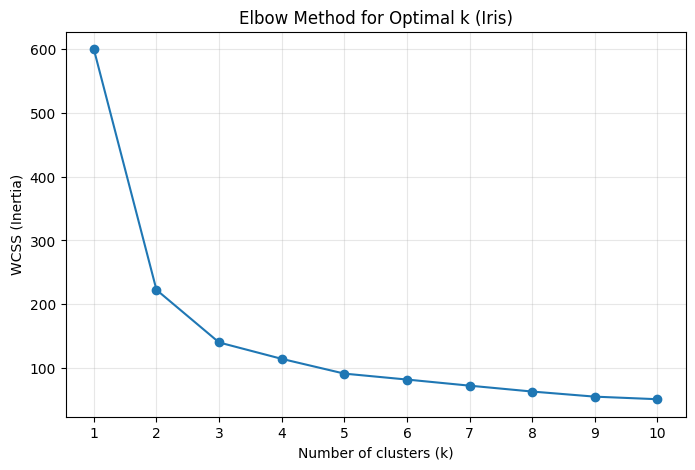

Image saved as elbow-1.jpg


In [4]:
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o')
plt.title("Elbow Method for Optimal k (Iris)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)

# Save required image
plt.savefig("elbow-1.jpg", dpi=200, bbox_inches="tight")

plt.show()

print("Image saved as elbow-1.jpg")

**Observation**

The optimal value of k is located at the “elbow” point where the reduction in WCSS begins to level off.

## Part 2: MNIST Logistic Regression With and Without PCA

Steps:
1. Load MNIST using OpenML
2. Split into training and testing sets
3. Apply StandardScaler
4. Train Logistic Regression without PCA
5. Apply PCA (95% variance)
6. Train Logistic Regression with PCA
7. Compare training time and accuracy

In [5]:
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [6]:
# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data.astype(np.float64)
y = mnist.target

print("Full dataset shape:", X.shape)

Full dataset shape: (70000, 784)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=11,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (56000, 784)
Testing set: (14000, 784)


In [8]:
scaler = StandardScaler()

start = time.perf_counter()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaling_time = time.perf_counter() - start

print(f"Scaling time: {scaling_time:.2f} seconds")

Scaling time: 1.83 seconds


In [9]:
logreg = LogisticRegression(solver='lbfgs', max_iter=500)

start = time.perf_counter()
logreg.fit(X_train_scaled, y_train)
train_time_no_pca = time.perf_counter() - start

start = time.perf_counter()
y_pred = logreg.predict(X_test_scaled)
predict_time_no_pca = time.perf_counter() - start

accuracy_no_pca = accuracy_score(y_test, y_pred)

print("\nWithout PCA")
print("Train time:", train_time_no_pca)
print("Predict time:", predict_time_no_pca)
print("Accuracy:", accuracy_no_pca)


Without PCA
Train time: 97.92974642000001
Predict time: 0.060378098000001046
Accuracy: 0.9132857142857143


In [10]:
pca = PCA(n_components=0.95)

start = time.perf_counter()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pca_time = time.perf_counter() - start

print("Original features:", X_train_scaled.shape[1])
print("Reduced features:", X_train_pca.shape[1])
print("PCA time:", pca_time)

Original features: 784
Reduced features: 331
PCA time: 5.2903157890000045


In [11]:
logreg_pca = LogisticRegression(solver='lbfgs', max_iter=500)

start = time.perf_counter()
logreg_pca.fit(X_train_pca, y_train)
train_time_pca = time.perf_counter() - start

start = time.perf_counter()
y_pred_pca = logreg_pca.predict(X_test_pca)
predict_time_pca = time.perf_counter() - start

accuracy_pca = accuracy_score(y_test, y_pred_pca)

print("\nWith PCA")
print("Train time:", train_time_pca)
print("Predict time:", predict_time_pca)
print("Accuracy:", accuracy_pca)


With PCA
Train time: 53.58031050400004
Predict time: 0.0219621619999657
Accuracy: 0.9219285714285714


In [12]:
print("\n====== Summary ======")
print(f"No PCA -> Train: {train_time_no_pca:.2f}s | Predict: {predict_time_no_pca:.2f}s | Accuracy: {accuracy_no_pca:.4f}")
print(f"With PCA -> PCA: {pca_time:.2f}s | Train: {train_time_pca:.2f}s | Predict: {predict_time_pca:.2f}s | Accuracy: {accuracy_pca:.4f}")

total_no_pca = scaling_time + train_time_no_pca + predict_time_no_pca
total_pca = scaling_time + pca_time + train_time_pca + predict_time_pca

print(f"\nTotal time without PCA: {total_no_pca:.2f}s")
print(f"Total time with PCA: {total_pca:.2f}s")

if total_pca > 0:
    print("Speedup factor:", total_no_pca / total_pca)


====== Summary ======
No PCA -> Train: 97.93s | Predict: 0.06s | Accuracy: 0.9133
With PCA -> PCA: 5.29s | Train: 53.58s | Predict: 0.02s | Accuracy: 0.9219

Total time without PCA: 99.82s
Total time with PCA: 60.72s
Speedup factor: 1.6439090308750897


## Conclusion

PCA significantly reduces the number of features while preserving 95% of the variance.  
This reduction typically decreases training time for Logistic Regression with only a small change in accuracy.

The results demonstrate that dimensionality reduction can improve computational efficiency for high-dimensional datasets such as MNIST.